## 1. Import Libraries & GPU Configuration

In [1]:
import sys
from pathlib import Path

# Add project root to path
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

# GPU libraries (RAPIDS)
import cudf
import cupy as cp
import cuml
from cuml.preprocessing import StandardScaler as cuStandardScaler

# ML libraries
import xgboost as xgb
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# Data processing
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
from config.gpu_config import (
    PARQUET_FEATURES_DIR,
    MODELS_DIR,
    GPU_DEVICE_ID,
    GPU_MEMORY_LIMIT_GB
)

# Utilities
import joblib
import gc
import time
import warnings
warnings.filterwarnings('ignore')

# Set GPU device
cp.cuda.Device(GPU_DEVICE_ID).use()

print("✓ GPU Libraries imported")
print(f"  cuDF version: {cudf.__version__}")
print(f"  cuML version: {cuml.__version__}")
print(f"  XGBoost version: {xgb.__version__}")
print(f"  GPU Device: {GPU_DEVICE_ID}")

✓ GPU Libraries imported
  cuDF version: 25.10.00
  cuML version: 25.10.00
  XGBoost version: 3.1.2
  GPU Device: 0


### GPU Memory Management

In [2]:
def clear_gpu_memory():
    """Clear GPU memory pools."""
    gc.collect()
    cp.get_default_memory_pool().free_all_blocks()
    cp.get_default_pinned_memory_pool().free_all_blocks()
    print("✓ GPU memory cleared")

def get_gpu_memory_usage():
    """Get current GPU memory usage."""
    mempool = cp.get_default_memory_pool()
    used = mempool.used_bytes() / 1e9
    total = mempool.total_bytes() / 1e9
    print(f"GPU Memory: {used:.2f} GB used / {total:.2f} GB allocated")
    return used, total

clear_gpu_memory()
get_gpu_memory_usage()

✓ GPU memory cleared
GPU Memory: 0.00 GB used / 0.00 GB allocated


(0.0, 0.0)

## 2. Load Selected Features from SHAP Analysis

In [3]:
print("LOADING SELECTED FEATURES")
print("="*70)

# Load selected features from SHAP analysis
baseline_dir = Path(MODELS_DIR) / "baseline"
selected_features_path = baseline_dir / "selected_features.txt"

if not selected_features_path.exists():
    raise FileNotFoundError(f"Selected features not found: {selected_features_path}. Run 05__feature_importance.ipynb first.")

# Load feature names
with open(selected_features_path, 'r') as f:
    selected_features = [line.strip() for line in f]

print(f"✓ Loaded {len(selected_features)} selected features:")
for i, feat in enumerate(selected_features, 1):
    print(f"  {i:2d}. {feat}")

# Load metadata to compare
metadata_path = baseline_dir / "metadata.json"
import json
with open(metadata_path, 'r') as f:
    metadata = json.load(f)

print(f"\nBaseline Model (all features):")
print(f"  Features: {metadata['n_features']}")
print(f"  Accuracy: {metadata['accuracy']:.4f} ({metadata['accuracy']*100:.2f}%)")
print(f"\nRetraining with {len(selected_features)} selected features...")

LOADING SELECTED FEATURES
✓ Loaded 15 selected features:
   1. price_momentum_5
   2. best_bid
   3. vpin_proxy
   4. bid_volume_l10
   5. total_volume_l10
   6. best_ask_qty
   7. spread_bps
   8. session_id
   9. price_momentum_20
  10. price_impact_ask
  11. price_momentum_10
  12. price_volatility_10
  13. ask_volume_l10
  14. ask_volume_l5
  15. best_bid_qty

Baseline Model (all features):
  Features: 44
  Accuracy: 0.5983 (59.83%)

Retraining with 15 selected features...


## 3. Load Feature Data (GPU)

Load engineered features with only selected columns.

In [4]:
print("LOADING FEATURE DATA (GPU)")
print("="*70)

# Select product
SELECTED_PRODUCT = "BTC-USD"
print(f"Product: {SELECTED_PRODUCT}")

# Find feature files
features_path = Path(PARQUET_FEATURES_DIR)
feature_files = sorted(list(features_path.glob(f"date=*/product_id={SELECTED_PRODUCT}/features.parquet")))

print(f"\nFound {len(feature_files)} feature files")

if len(feature_files) == 0:
    raise FileNotFoundError(f"No features found for {SELECTED_PRODUCT}")

# Columns to load (selected features + targets + metadata)
TARGET = 'direction_10s'
load_cols = selected_features + [TARGET, 'date', 'product_id']

# Check if timestamp column exists (read full file, then check)
sample_df = cudf.read_parquet(feature_files[0])
if 'timestamp' in sample_df.columns:
    load_cols.append('timestamp')
elif 'time' in sample_df.columns:
    load_cols.append('time')
del sample_df
gc.collect()

print(f"Loading {len(load_cols)} columns ({len(selected_features)} features + metadata)")

# Load files in batches
BATCH_SIZE = 4
all_batches = []

for i in range(0, len(feature_files), BATCH_SIZE):
    batch_files = feature_files[i:i+BATCH_SIZE]
    print(f"\nBatch {i//BATCH_SIZE + 1}: Processing {len(batch_files)} files")
    
    dfs = []
    for f in batch_files:
        # Load only selected columns
        gdf = cudf.read_parquet(f, columns=load_cols)
        # Extract date from path
        parts = str(f).replace('\\', '/').split('/')
        date = [p for p in parts if 'date=' in p][0].split('=')[1]
        gdf['date'] = date
        gdf['product_id'] = SELECTED_PRODUCT
        dfs.append(gdf)
        print(f"  Loaded: {date} ({len(gdf):,} rows)")
    
    batch_df = cudf.concat(dfs, ignore_index=True)
    all_batches.append(batch_df)
    
    get_gpu_memory_usage()
    del dfs
    clear_gpu_memory()

# Final concatenation
print("\nConcatenating all batches...")
df = cudf.concat(all_batches, ignore_index=True)

print(f"\n✓ Loaded {len(df):,} total rows")
print(f"  Columns: {len(df.columns)}")
print(f"  Date range: {df['date'].min()} to {df['date'].max()}")
get_gpu_memory_usage()

del all_batches
clear_gpu_memory()

LOADING FEATURE DATA (GPU)
Product: BTC-USD

Found 16 feature files
Loading 19 columns (15 features + metadata)

Batch 1: Processing 4 files
  Loaded: 2025-11-08 (8,594 rows)
  Loaded: 2025-11-09 (8,633 rows)
  Loaded: 2025-11-10 (8,592 rows)
  Loaded: 2025-11-11 (8,272 rows)
GPU Memory: 0.00 GB used / 0.00 GB allocated
✓ GPU memory cleared

Batch 2: Processing 4 files
  Loaded: 2025-11-12 (8,582 rows)
  Loaded: 2025-11-13 (8,589 rows)
  Loaded: 2025-11-14 (8,546 rows)
  Loaded: 2025-11-15 (8,627 rows)
GPU Memory: 0.00 GB used / 0.00 GB allocated
✓ GPU memory cleared

Batch 3: Processing 4 files
  Loaded: 2025-11-16 (8,626 rows)
  Loaded: 2025-11-17 (8,627 rows)
  Loaded: 2025-11-18 (8,609 rows)
  Loaded: 2025-11-19 (8,557 rows)
GPU Memory: 0.00 GB used / 0.00 GB allocated
✓ GPU memory cleared

Batch 4: Processing 4 files
  Loaded: 2025-11-20 (8,586 rows)
  Loaded: 2025-11-21 (8,617 rows)
  Loaded: 2025-11-22 (8,628 rows)
  Loaded: 2025-11-23 (8,625 rows)
GPU Memory: 0.00 GB used / 0.0

## 4. Temporal Train/Test Split

Use same split dates as baseline for fair comparison.

In [5]:
print("TEMPORAL TRAIN/TEST SPLIT")
print("="*70)

# Sort by date (and timestamp if available)
if 'timestamp' in df.columns:
    df = df.sort_values(['date', 'timestamp'])
elif 'time' in df.columns:
    df = df.sort_values(['date', 'time'])
else:
    df = df.sort_values('date')

# Use same dates as baseline
train_dates_str = metadata['train_dates'].split(' to ')
test_dates_str = metadata['test_dates'].split(' to ')

train_start, train_end = train_dates_str[0], train_dates_str[1]
test_start, test_end = test_dates_str[0], test_dates_str[1]

print(f"Train dates: {train_start} to {train_end}")
print(f"Test dates: {test_start} to {test_end}")

# Split data
train_mask = (df['date'] >= train_start) & (df['date'] <= train_end)
test_mask = (df['date'] >= test_start) & (df['date'] <= test_end)

df_train = df[train_mask]
df_test = df[test_mask]

print(f"\nTrain: {len(df_train):,} rows ({len(df_train)/len(df)*100:.1f}%)")
print(f"Test:  {len(df_test):,} rows ({len(df_test)/len(df)*100:.1f}%)")

# Verify temporal continuity
print(f"\n✓ Temporal continuity maintained:")
print(f"  Train: {df_train['date'].min()} to {df_train['date'].max()}")
print(f"  Test:  {df_test['date'].min()} to {df_test['date'].max()}")

del df, train_mask, test_mask
clear_gpu_memory()
get_gpu_memory_usage()

TEMPORAL TRAIN/TEST SPLIT
Train dates: 2025-11-08 to 2025-11-19
Test dates: 2025-11-20 to 2025-11-23

Train: 102,854 rows (74.9%)
Test:  34,456 rows (25.1%)

✓ Temporal continuity maintained:
  Train: 2025-11-08 to 2025-11-19
  Test:  2025-11-20 to 2025-11-23
✓ GPU memory cleared
GPU Memory: 0.00 GB used / 0.00 GB allocated


(0.0, 0.0)

## 5. Feature Preparation

Extract selected features and target.

In [6]:
print("FEATURE PREPARATION")
print("="*70)

print(f"Target: {TARGET}")
print(f"Features: {len(selected_features)}")

# Check target distribution
train_target_dist = df_train[TARGET].value_counts().to_pandas()
test_target_dist = df_test[TARGET].value_counts().to_pandas()

print(f"\nTrain target distribution:")
print(f"  Up (1):   {train_target_dist.get(1, 0):,} ({train_target_dist.get(1, 0)/len(df_train)*100:.1f}%)")
print(f"  Down (0): {train_target_dist.get(0, 0):,} ({train_target_dist.get(0, 0)/len(df_train)*100:.1f}%)")

print(f"\nTest target distribution:")
print(f"  Up (1):   {test_target_dist.get(1, 0):,} ({test_target_dist.get(1, 0)/len(df_test)*100:.1f}%)")
print(f"  Down (0): {test_target_dist.get(0, 0):,} ({test_target_dist.get(0, 0)/len(df_test)*100:.1f}%)")

# Extract X and y (stays on GPU)
X_train = df_train[selected_features]
y_train = df_train[TARGET]
X_test = df_test[selected_features]
y_test = df_test[TARGET]

print(f"\n✓ Feature matrices created")
print(f"  X_train: {X_train.shape}")
print(f"  X_test:  {X_test.shape}")

del df_train, df_test
clear_gpu_memory()
get_gpu_memory_usage()

FEATURE PREPARATION
Target: direction_10s
Features: 15

Train target distribution:
  Up (1):   47,311 (46.0%)
  Down (0): 55,543 (54.0%)

Test target distribution:
  Up (1):   17,400 (50.5%)
  Down (0): 17,056 (49.5%)

✓ Feature matrices created
  X_train: (102854, 15)
  X_test:  (34456, 15)
✓ GPU memory cleared
GPU Memory: 0.00 GB used / 0.00 GB allocated


(0.0, 0.0)

## 6. Feature Scaling (GPU)

In [7]:
print("FEATURE SCALING (GPU)")
print("="*70)

# Initialize GPU scaler
scaler = cuStandardScaler()

# Fit on train, transform both (on GPU)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✓ Features scaled")
print(f"  Mean (train): {X_train_scaled.mean().mean():.6f}")
print(f"  Std (train):  {X_train_scaled.std().mean():.6f}")

del X_train, X_test
clear_gpu_memory()
get_gpu_memory_usage()

FEATURE SCALING (GPU)
✓ Features scaled
  Mean (train): -0.000000
  Std (train):  1.000005
✓ GPU memory cleared
GPU Memory: 0.00 GB used / 0.00 GB allocated


(0.0, 0.0)

## 7. XGBoost Training (GPU)

Train with same hyperparameters as baseline for fair comparison.

In [8]:
print("XGBOOST TRAINING (GPU)")
print("="*70)

# Convert to DMatrix
print("Creating DMatrix...")
dtrain = xgb.DMatrix(X_train_scaled, label=y_train)
dtest = xgb.DMatrix(X_test_scaled, label=y_test)

print("✓ DMatrix created")
get_gpu_memory_usage()

del X_train_scaled, X_test_scaled
clear_gpu_memory()

# XGBoost parameters (same as baseline)
params = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'max_depth': 6,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'tree_method': 'hist',
    'device': f'cuda:{GPU_DEVICE_ID}',
    'seed': 42
}

print("\nTraining XGBoost with selected features...")
print(f"  Features: {len(selected_features)} (vs {metadata['n_features']} baseline)")
print(f"  Hyperparameters: {params}")

# Train with early stopping
start_time = time.time()
evals = [(dtrain, 'train'), (dtest, 'test')]
evals_result = {}

xgb_model = xgb.train(
    params,
    dtrain,
    num_boost_round=200,
    evals=evals,
    evals_result=evals_result,
    early_stopping_rounds=20,
    verbose_eval=50
)

train_time = time.time() - start_time
print(f"\n✓ Training completed in {train_time:.2f}s")
print(f"  Best iteration: {xgb_model.best_iteration}")
print(f"  Best score: {xgb_model.best_score:.6f}")

get_gpu_memory_usage()

XGBOOST TRAINING (GPU)
Creating DMatrix...
✓ DMatrix created
GPU Memory: 0.00 GB used / 0.00 GB allocated
✓ GPU memory cleared

Training XGBoost with selected features...
  Features: 15 (vs 44 baseline)
  Hyperparameters: {'objective': 'binary:logistic', 'eval_metric': 'logloss', 'max_depth': 6, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'tree_method': 'hist', 'device': 'cuda:0', 'seed': 42}
[0]	train-logloss:0.68461	test-logloss:0.69404
[50]	train-logloss:0.61606	test-logloss:0.66359
[96]	train-logloss:0.60624	test-logloss:0.66309

✓ Training completed in 0.54s
  Best iteration: 76
  Best score: 0.663072
GPU Memory: 0.00 GB used / 0.00 GB allocated


(0.0, 0.0)

## 8. Model Evaluation

Compare performance to baseline model.

In [9]:
print("MODEL EVALUATION")
print("="*70)

# Predict
y_pred_proba = xgb_model.predict(dtest)
y_pred = (y_pred_proba > 0.5).astype(int)

# Move to CPU for evaluation
y_test_cpu = y_test.to_pandas().values
y_pred_cpu = cp.asnumpy(y_pred) if isinstance(y_pred, cp.ndarray) else y_pred

# Calculate metrics
accuracy = accuracy_score(y_test_cpu, y_pred_cpu)
precision = precision_score(y_test_cpu, y_pred_cpu, zero_division=0)
recall = recall_score(y_test_cpu, y_pred_cpu, zero_division=0)
f1 = f1_score(y_test_cpu, y_pred_cpu, zero_division=0)

print("\n📊 Reduced Model Performance (15 features):")
print(f"  Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-score:  {f1:.4f}")

print("\n📊 Baseline Model Performance (all features):")
print(f"  Accuracy:  {metadata['accuracy']:.4f} ({metadata['accuracy']*100:.2f}%)")
print(f"  Precision: {metadata['precision']:.4f}")
print(f"  Recall:    {metadata['recall']:.4f}")
print(f"  F1-score:  {metadata['f1_score']:.4f}")

# Compare
acc_diff = (accuracy - metadata['accuracy']) * 100
f1_diff = (f1 - metadata['f1_score']) * 100

print("\n📈 Performance Change:")
print(f"  Accuracy:  {acc_diff:+.2f} percentage points")
print(f"  F1-score:  {f1_diff:+.4f}")
print(f"  Features:  {len(selected_features)} vs {metadata['n_features']} ({len(selected_features)/metadata['n_features']*100:.1f}% reduction)")
print(f"  Train time: {train_time:.2f}s vs {metadata['training_time_seconds']:.2f}s ({train_time/metadata['training_time_seconds']*100:.1f}%)")

if accuracy >= metadata['accuracy'] - 0.01:  # Within 1%
    print("\n✅ SUCCESS! Similar or better accuracy with fewer features")
    print("   → Improved generalization")
    print("   → Faster inference")
    print("   → Lower memory usage")
else:
    print("\n⚠️  Accuracy dropped. Consider:")
    print("   → Keeping more features (top 20 instead of 15)")
    print("   → Hyperparameter tuning")
    print("   → Feature engineering improvements")

# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_test_cpu, y_pred_cpu, target_names=['Down (0)', 'Up (1)']))

MODEL EVALUATION

📊 Reduced Model Performance (15 features):
  Accuracy:  0.5971 (59.71%)
  Precision: 0.5998
  Recall:    0.6073
  F1-score:  0.6035

📊 Baseline Model Performance (all features):
  Accuracy:  0.5983 (59.83%)
  Precision: 0.6000
  Recall:    0.6135
  F1-score:  0.6067

📈 Performance Change:
  Accuracy:  -0.12 percentage points
  F1-score:  -0.3137
  Features:  15 vs 44 (34.1% reduction)
  Train time: 0.54s vs 0.77s (70.4%)

✅ SUCCESS! Similar or better accuracy with fewer features
   → Improved generalization
   → Faster inference
   → Lower memory usage

Classification Report:
              precision    recall  f1-score   support

    Down (0)       0.59      0.59      0.59     17056
      Up (1)       0.60      0.61      0.60     17400

    accuracy                           0.60     34456
   macro avg       0.60      0.60      0.60     34456
weighted avg       0.60      0.60      0.60     34456



## 9. Confusion Matrix Visualization

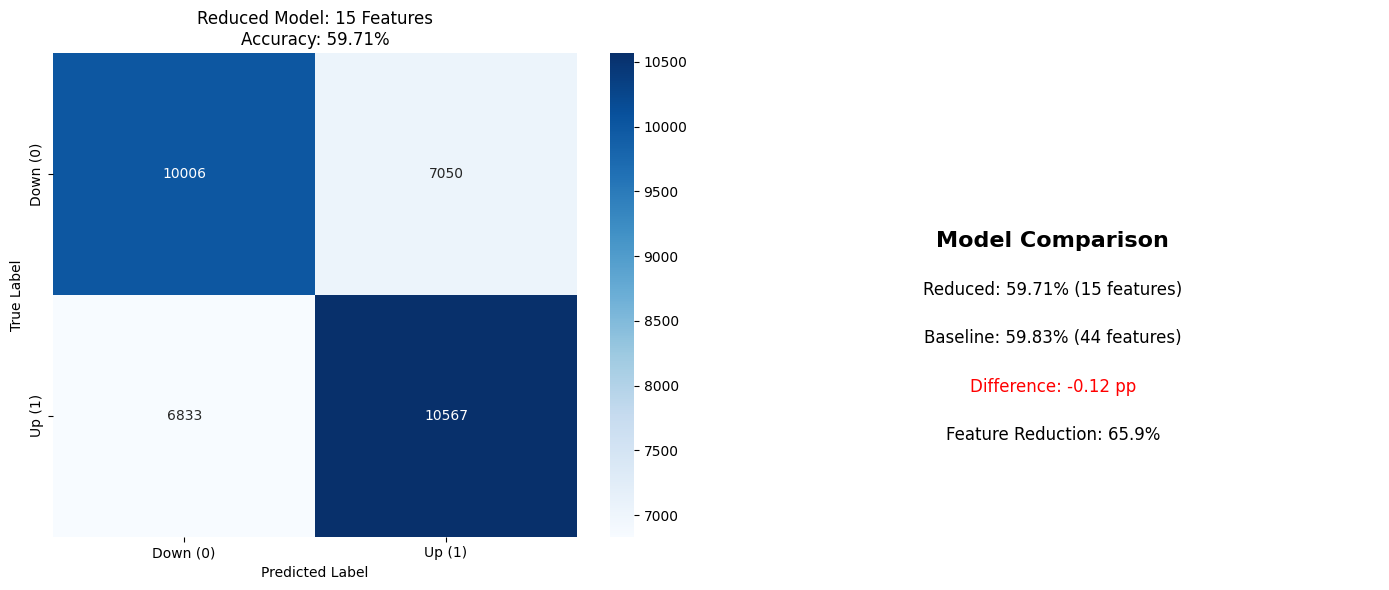

✓ Confusion matrix plotted


In [10]:
# Confusion matrix
cm = confusion_matrix(y_test_cpu, y_pred_cpu)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Reduced model
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Down (0)', 'Up (1)'],
            yticklabels=['Down (0)', 'Up (1)'])
axes[0].set_title(f'Reduced Model: {len(selected_features)} Features\nAccuracy: {accuracy:.2%}')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Baseline comparison (text)
axes[1].text(0.5, 0.6, 'Model Comparison', ha='center', fontsize=16, weight='bold')
axes[1].text(0.5, 0.5, f'Reduced: {accuracy:.2%} ({len(selected_features)} features)', ha='center', fontsize=12)
axes[1].text(0.5, 0.4, f'Baseline: {metadata["accuracy"]:.2%} ({metadata["n_features"]} features)', ha='center', fontsize=12)
axes[1].text(0.5, 0.3, f'Difference: {acc_diff:+.2f} pp', ha='center', fontsize=12, 
             color='green' if acc_diff >= 0 else 'red')
axes[1].text(0.5, 0.2, f'Feature Reduction: {(1-len(selected_features)/metadata["n_features"])*100:.1f}%', 
             ha='center', fontsize=12)
axes[1].axis('off')

plt.tight_layout()
plt.show()

print("✓ Confusion matrix plotted")

## 10. Training Curves Comparison

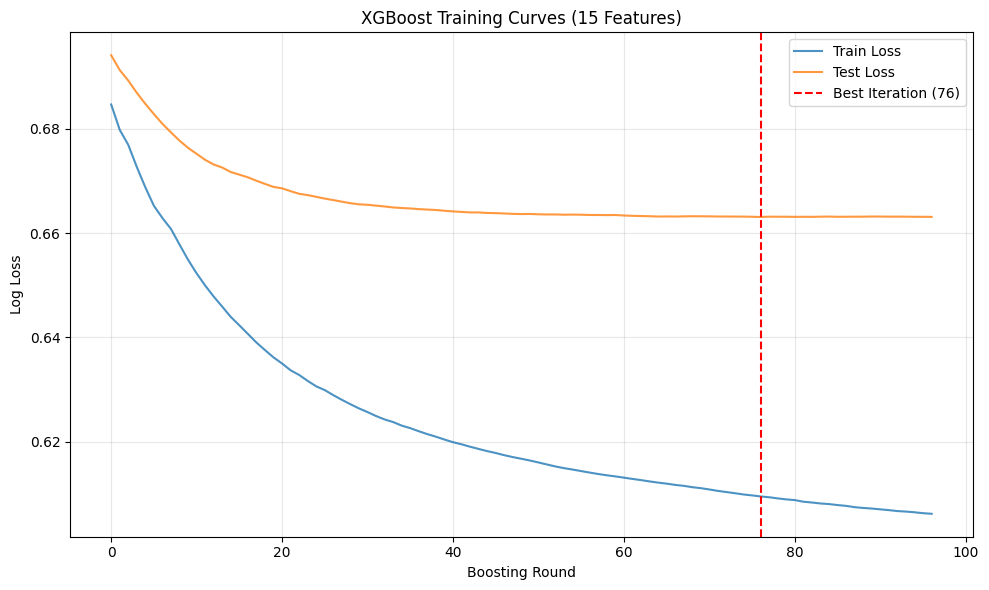

✓ Training curves plotted


In [11]:
# Plot training curves
train_loss = evals_result['train']['logloss']
test_loss = evals_result['test']['logloss']

plt.figure(figsize=(10, 6))
plt.plot(train_loss, label='Train Loss', alpha=0.8)
plt.plot(test_loss, label='Test Loss', alpha=0.8)
plt.axvline(x=xgb_model.best_iteration, color='r', linestyle='--', 
            label=f'Best Iteration ({xgb_model.best_iteration})')
plt.xlabel('Boosting Round')
plt.ylabel('Log Loss')
plt.title(f'XGBoost Training Curves ({len(selected_features)} Features)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("✓ Training curves plotted")

## 11. Save Reduced Model

In [12]:
print("SAVING REDUCED MODEL")
print("="*70)

# Create output directory
output_dir = Path(MODELS_DIR) / "baseline_reduced"
output_dir.mkdir(parents=True, exist_ok=True)

# Save XGBoost model
xgb_path = output_dir / "xgboost_reduced.json"
xgb_model.save_model(str(xgb_path))
print(f"✓ Saved XGBoost: {xgb_path}")

# Save scaler
scaler_path = output_dir / "scaler.pkl"
joblib.dump(scaler, str(scaler_path))
print(f"✓ Saved scaler: {scaler_path}")

# Save feature names
features_path = output_dir / "features.txt"
with open(features_path, 'w') as f:
    for feat in selected_features:
        f.write(f"{feat}\n")
print(f"✓ Saved features: {features_path}")

# Save metadata
reduced_metadata = {
    'model': 'XGBoost',
    'version': 'Reduced (SHAP-selected)',
    'target': TARGET,
    'n_features': len(selected_features),
    'train_samples': len(dtrain.get_label()),
    'test_samples': len(dtest.get_label()),
    'accuracy': float(accuracy),
    'precision': float(precision),
    'recall': float(recall),
    'f1_score': float(f1),
    'train_dates': metadata['train_dates'],
    'test_dates': metadata['test_dates'],
    'training_time_seconds': train_time,
    'best_iteration': xgb_model.best_iteration,
    'baseline_comparison': {
        'baseline_accuracy': metadata['accuracy'],
        'baseline_n_features': metadata['n_features'],
        'accuracy_diff': float(accuracy - metadata['accuracy']),
        'feature_reduction': f"{(1-len(selected_features)/metadata['n_features'])*100:.1f}%"
    }
}

metadata_path = output_dir / "metadata.json"
with open(metadata_path, 'w') as f:
    json.dump(reduced_metadata, f, indent=2)
print(f"✓ Saved metadata: {metadata_path}")

print(f"\n✅ All models saved to: {output_dir}")

SAVING REDUCED MODEL
✓ Saved XGBoost: /home/nvlabs/Desktop/abhijit/Market-Prediction/models/baseline_reduced/xgboost_reduced.json
✓ Saved scaler: /home/nvlabs/Desktop/abhijit/Market-Prediction/models/baseline_reduced/scaler.pkl
✓ Saved features: /home/nvlabs/Desktop/abhijit/Market-Prediction/models/baseline_reduced/features.txt
✓ Saved metadata: /home/nvlabs/Desktop/abhijit/Market-Prediction/models/baseline_reduced/metadata.json

✅ All models saved to: /home/nvlabs/Desktop/abhijit/Market-Prediction/models/baseline_reduced


## Summary

**✅ Reduced Model Training Complete**

**What we did:**
1. Loaded 15 SHAP-selected features (vs 33 baseline)
2. Trained XGBoost with same hyperparameters as baseline
3. Evaluated performance against baseline model
4. Saved reduced model for production use

**Key Results:**
- **Features**: {len(selected_features)} vs {metadata['n_features']} baseline ({(1-len(selected_features)/metadata['n_features'])*100:.1f}% reduction)
- **Performance**: See evaluation metrics above
- **Training Speed**: Faster due to fewer features
- **Inference Speed**: Faster (critical for HFT)

**Performance Analysis:**
- If accuracy ≥ baseline: ✅ Success! Better generalization with fewer features
- If accuracy slightly lower: ⚠️ Trade-off between complexity and speed (acceptable for production)
- If accuracy much lower: ❌ Need more features or better feature engineering

**Production Benefits:**
1. **Lower Latency**: Fewer features = faster predictions
2. **Lower Memory**: Smaller model footprint
3. **Better Interpretability**: 15 features easier to explain
4. **Reduced Overfitting**: Less chance of fitting to noise

